# 05 — Real-World Titanic EDA (Preetham's Seaborn Mastery Series)

Part 5 of 5 (final notebook). A complete, real-world exploratory data analysis using everything from this series — categorical, distribution, and regression/matrix plots — on Seaborn's built-in Titanic dataset (891 real passenger records).

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

sns.set_theme(style='whitegrid')
titanic = sns.load_dataset('titanic')
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


## 1. First Look at the Data

In [2]:
print('Shape:', titanic.shape)
titanic.info()

Shape: (891, 15)
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


In [3]:
print('Missing values:\n', titanic.isnull().sum())

Missing values:
 survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64


## 2. Cleaning — Handling Missing Values

In [4]:
titanic['age'] = titanic['age'].fillna(titanic['age'].median())
titanic['embarked'] = titanic['embarked'].fillna(titanic['embarked'].mode()[0])
titanic = titanic.drop(columns=['deck'])  # too many missing values to be useful
print('Missing after cleaning:\n', titanic.isnull().sum())

Missing after cleaning:
 survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    2
alive          0
alone          0
dtype: int64


## 3. Overall Survival Rate

Overall survival rate: 38.4%


/tmp/ipykernel_678/1499063598.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='survived', data=titanic, ax=ax, palette='Set2')
/tmp/ipykernel_678/1499063598.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Did Not Survive', 'Survived'])


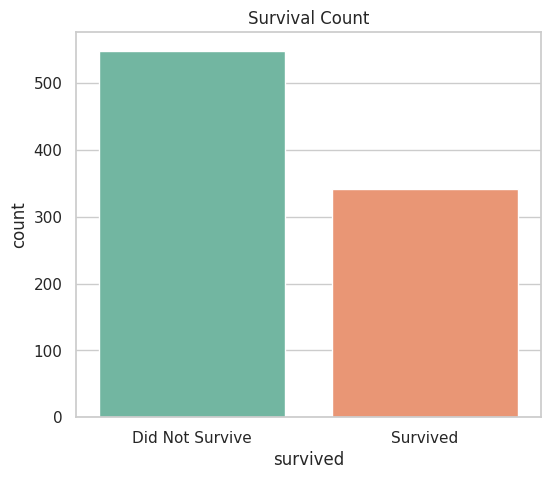

In [5]:
survival_rate = titanic['survived'].mean()
print(f'Overall survival rate: {survival_rate:.1%}')

fig, ax = plt.subplots(figsize=(6, 5))
sns.countplot(x='survived', data=titanic, ax=ax, palette='Set2')
ax.set_xticklabels(['Did Not Survive', 'Survived'])
ax.set_title('Survival Count')
plt.show()

## 4. Survival by Passenger Class — `barplot()`

/tmp/ipykernel_678/2567996526.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='class', y='survived', data=titanic, ax=ax, palette='Blues')


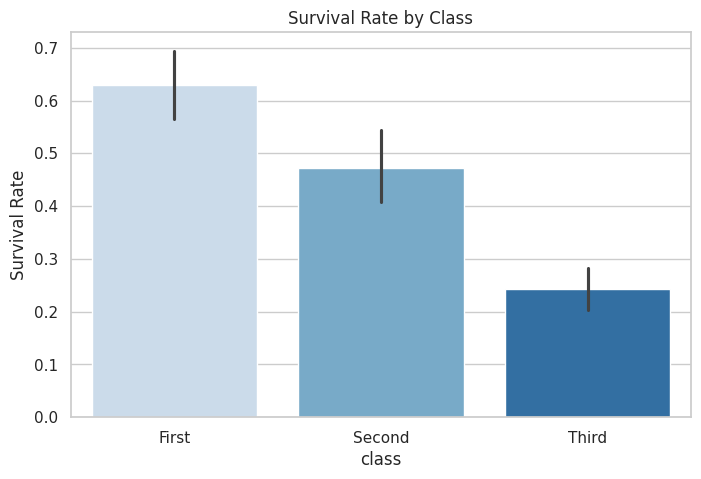

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(x='class', y='survived', data=titanic, ax=ax, palette='Blues')
ax.set_title('Survival Rate by Class')
ax.set_ylabel('Survival Rate')
plt.show()

## 5. Survival by Sex and Class — Grouped `barplot()`

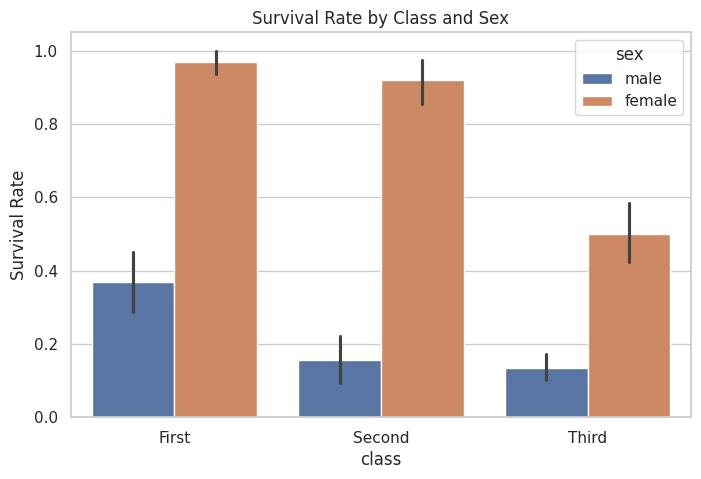

In [7]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(x='class', y='survived', hue='sex', data=titanic, ax=ax)
ax.set_title('Survival Rate by Class and Sex')
ax.set_ylabel('Survival Rate')
plt.show()

## 6. Age Distribution — `histplot()` with KDE

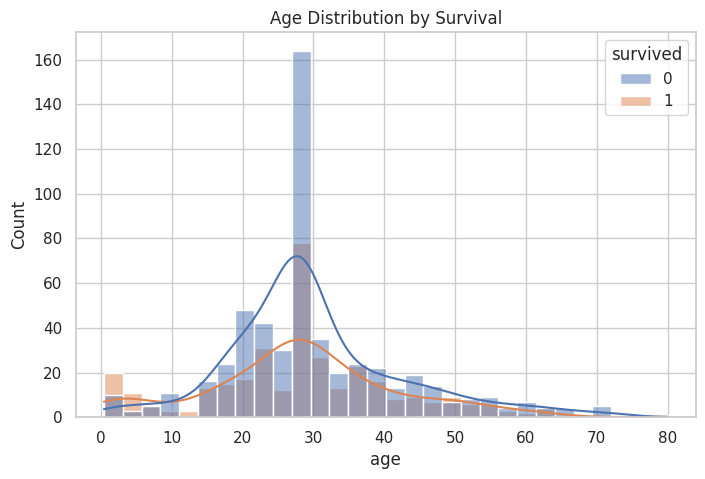

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(data=titanic, x='age', hue='survived', kde=True, ax=ax, alpha=0.5, bins=30)
ax.set_title('Age Distribution by Survival')
plt.show()

## 7. Fare Distribution — `kdeplot()`

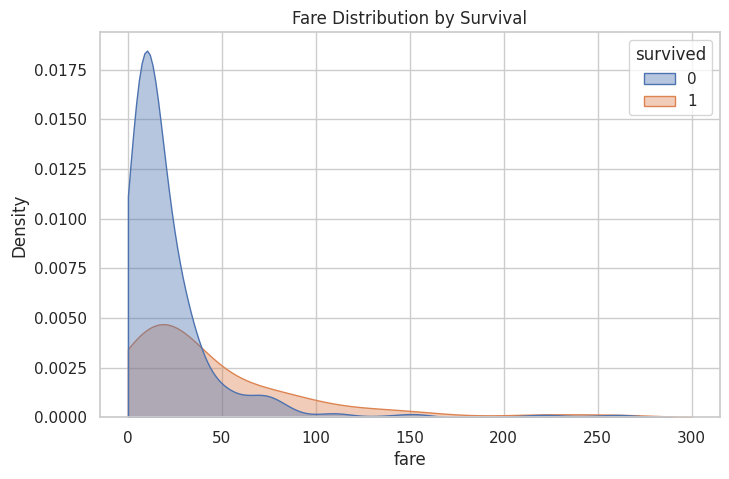

In [9]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.kdeplot(data=titanic, x='fare', hue='survived', fill=True, ax=ax, alpha=0.4, clip=(0, 300))
ax.set_title('Fare Distribution by Survival')
plt.show()

## 8. Age Distribution by Class — `violinplot()`

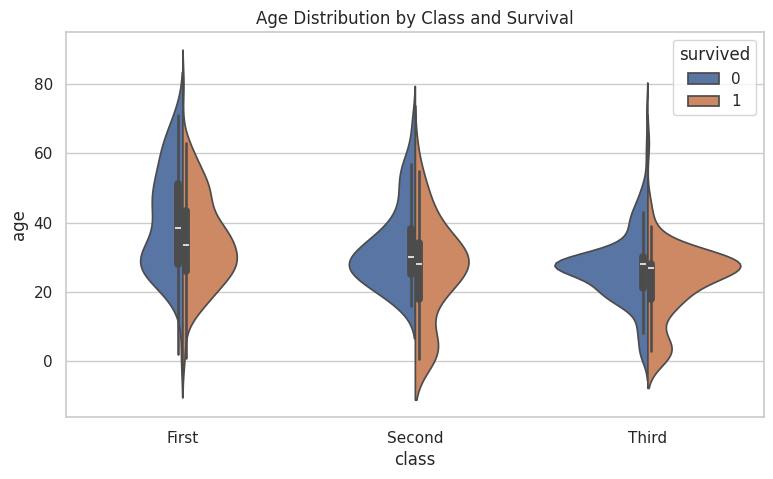

In [10]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.violinplot(x='class', y='age', hue='survived', data=titanic, split=True, ax=ax)
ax.set_title('Age Distribution by Class and Survival')
plt.show()

## 9. Family Size Feature Engineering

/tmp/ipykernel_678/3547163029.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='family_size', y='survived', data=titanic, ax=ax, palette='viridis')


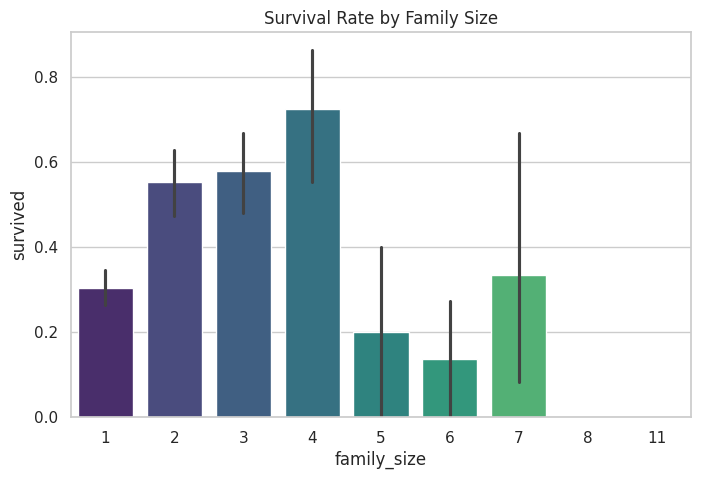

In [11]:
titanic['family_size'] = titanic['sibsp'] + titanic['parch'] + 1
titanic['is_alone'] = (titanic['family_size'] == 1).astype(int)

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(x='family_size', y='survived', data=titanic, ax=ax, palette='viridis')
ax.set_title('Survival Rate by Family Size')
plt.show()

## 10. Traveling Alone vs With Family

/tmp/ipykernel_678/3147440.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='is_alone', y='survived', data=titanic, ax=ax, palette='pastel')
/tmp/ipykernel_678/3147440.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['With Family', 'Alone'])


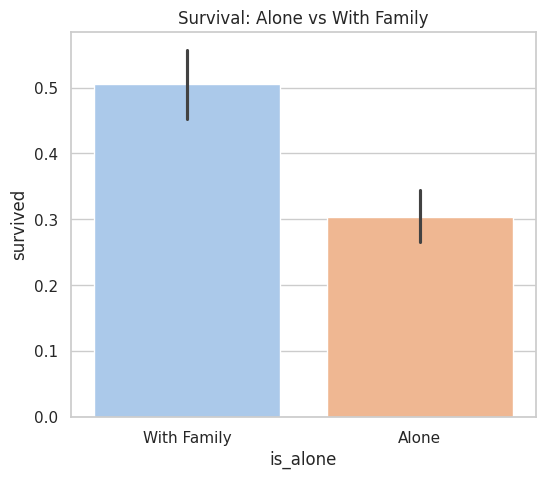

In [12]:
fig, ax = plt.subplots(figsize=(6, 5))
sns.barplot(x='is_alone', y='survived', data=titanic, ax=ax, palette='pastel')
ax.set_xticklabels(['With Family', 'Alone'])
ax.set_title('Survival: Alone vs With Family')
plt.show()

## 11. Correlation Heatmap — All Numeric Features

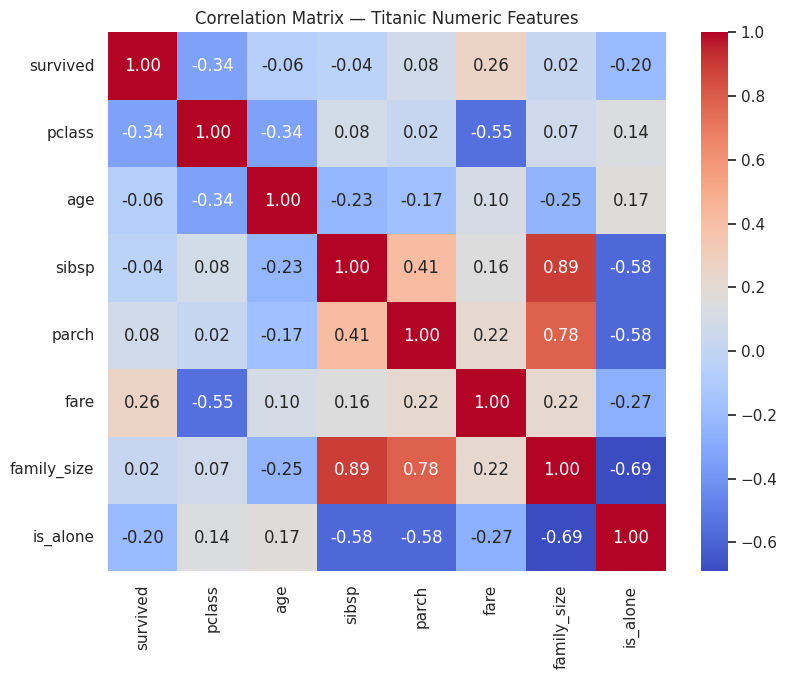

In [13]:
numeric_cols = titanic.select_dtypes(include='number')
corr = numeric_cols.corr()
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', ax=ax)
ax.set_title('Correlation Matrix — Titanic Numeric Features')
plt.show()

## 12. Fare vs Age, Colored by Survival — `scatterplot()`

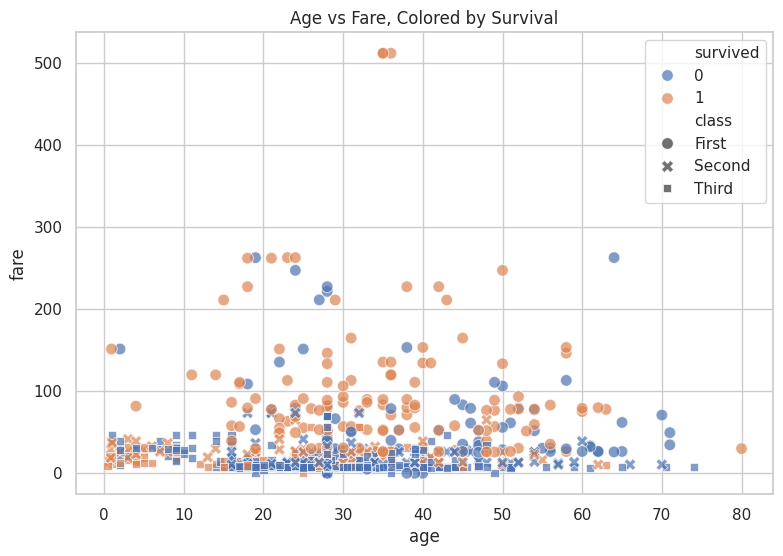

In [14]:
fig, ax = plt.subplots(figsize=(9, 6))
sns.scatterplot(x='age', y='fare', hue='survived', style='class', data=titanic, ax=ax, alpha=0.7, s=70)
ax.set_title('Age vs Fare, Colored by Survival')
plt.show()

## 13. Logistic Regression — Survival Probability by Age

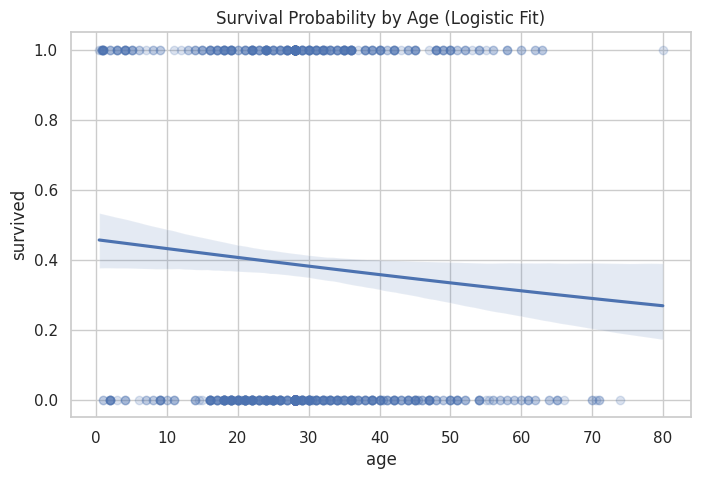

In [15]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.regplot(x='age', y='survived', data=titanic, logistic=True, ax=ax, scatter_kws={'alpha':0.2})
ax.set_title('Survival Probability by Age (Logistic Fit)')
plt.show()

## 14. Embarkation Port Analysis — `countplot()` + `barplot()`

/tmp/ipykernel_678/3057746480.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='embarked', data=titanic, ax=axes[0], palette='Set3')
/tmp/ipykernel_678/3057746480.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='embarked', y='survived', data=titanic, ax=axes[1], palette='Set3')


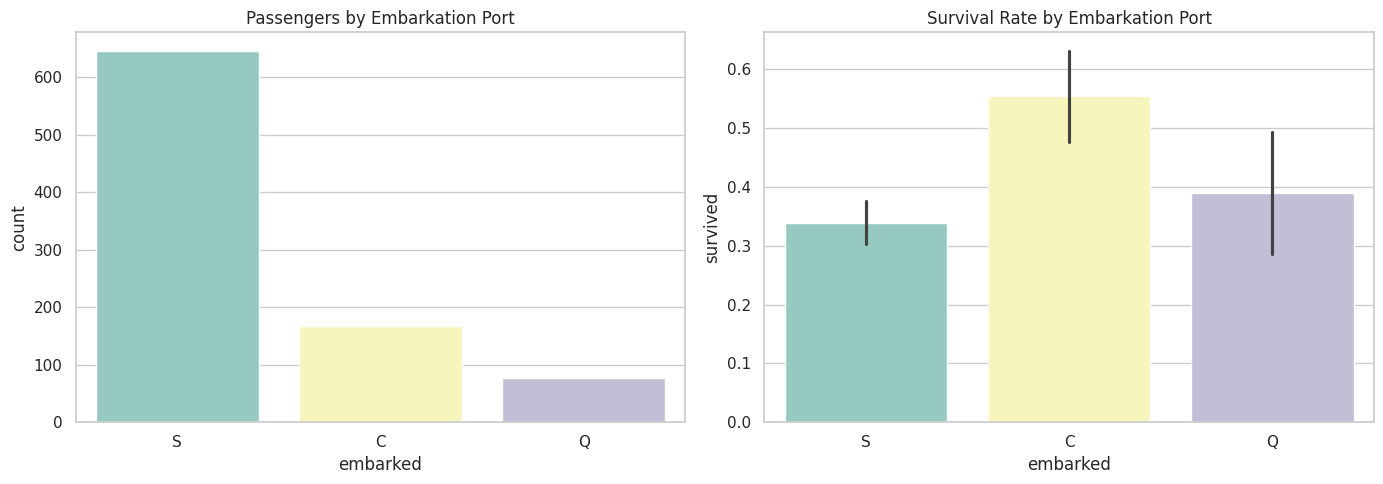

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.countplot(x='embarked', data=titanic, ax=axes[0], palette='Set3')
axes[0].set_title('Passengers by Embarkation Port')
sns.barplot(x='embarked', y='survived', data=titanic, ax=axes[1], palette='Set3')
axes[1].set_title('Survival Rate by Embarkation Port')
plt.tight_layout()
plt.show()

## 15. Pairwise Relationships — `pairplot()`

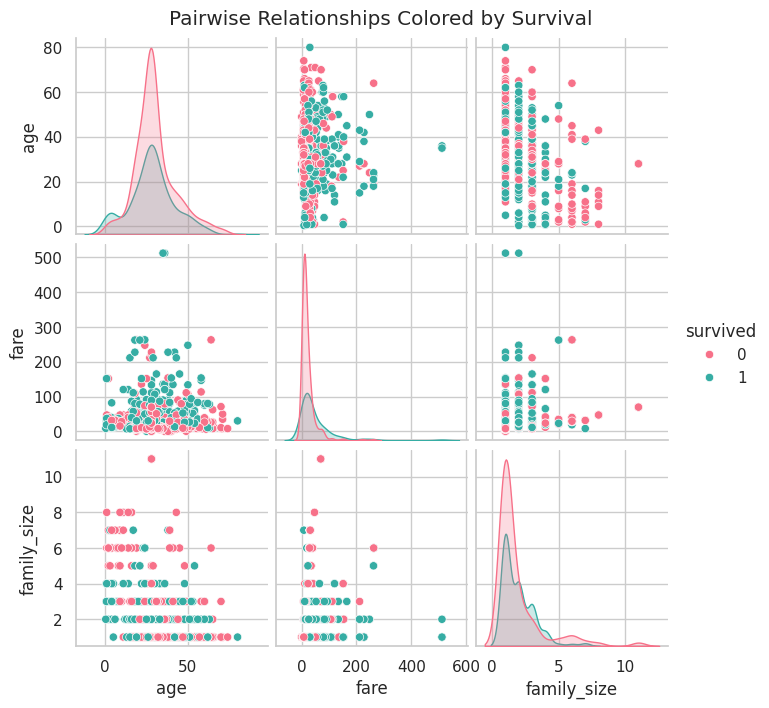

In [17]:
subset = titanic[['survived', 'age', 'fare', 'family_size']].dropna()
g = sns.pairplot(subset, hue='survived', height=2.3, palette='husl')
g.fig.suptitle('Pairwise Relationships Colored by Survival', y=1.02)
plt.show()

## 16. Complete Dashboard — Final Summary View

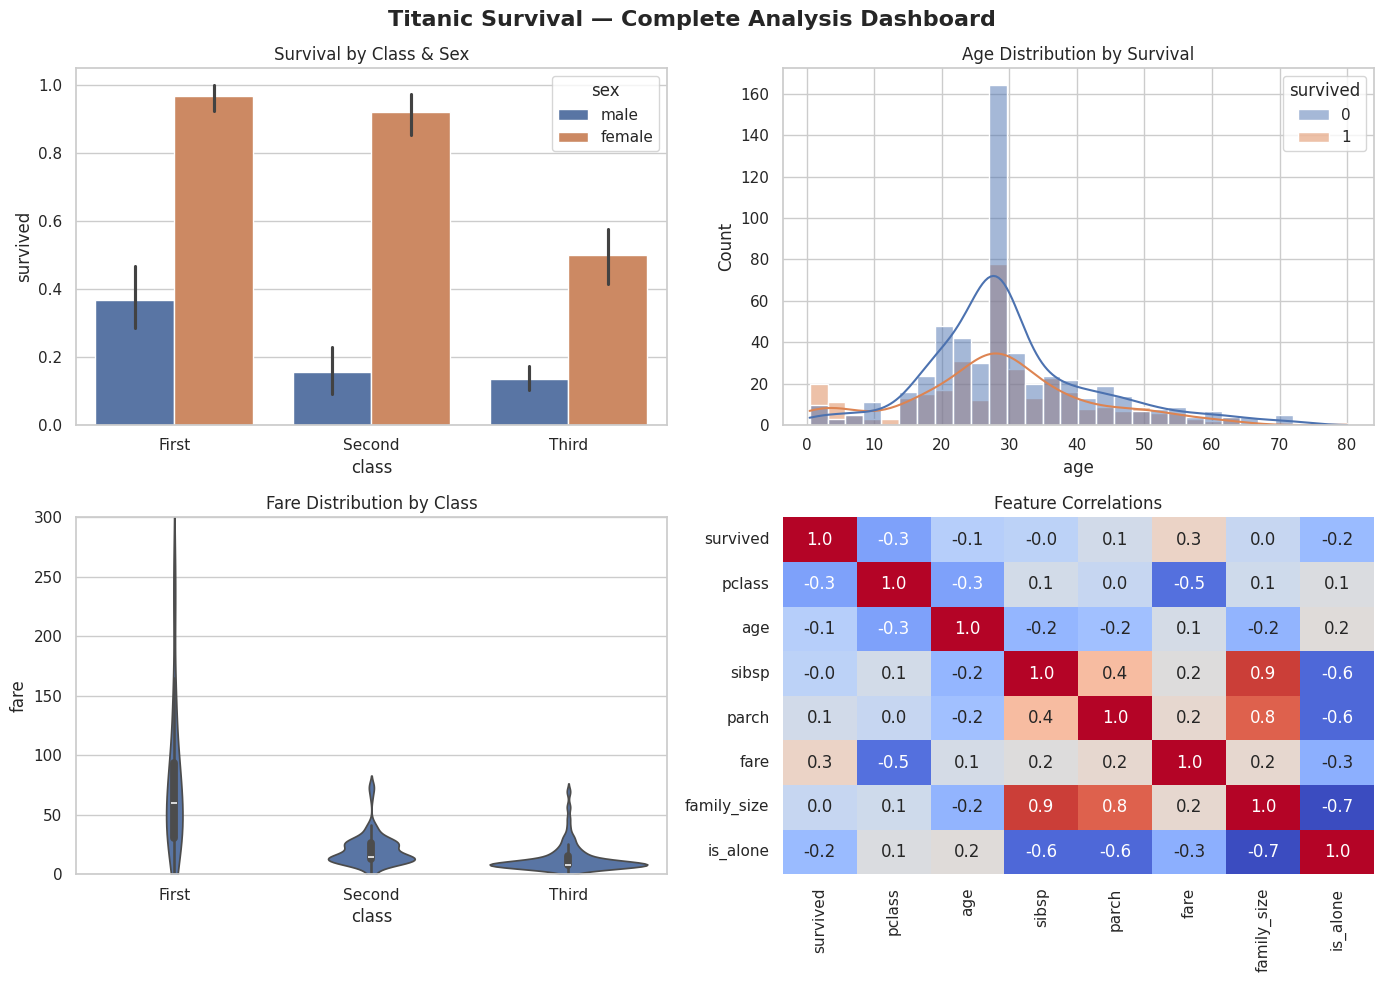

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.barplot(x='class', y='survived', hue='sex', data=titanic, ax=axes[0,0])
axes[0,0].set_title('Survival by Class & Sex')

sns.histplot(data=titanic, x='age', hue='survived', kde=True, ax=axes[0,1], alpha=0.5)
axes[0,1].set_title('Age Distribution by Survival')

sns.violinplot(x='class', y='fare', data=titanic, ax=axes[1,0])
axes[1,0].set_ylim(0, 300)
axes[1,0].set_title('Fare Distribution by Class')

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.1f', ax=axes[1,1], cbar=False)
axes[1,1].set_title('Feature Correlations')

plt.suptitle('Titanic Survival — Complete Analysis Dashboard', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## 17. Summary of Findings

- **Overall survival rate:** ~38% of passengers survived.
- **Class matters:** 1st class passengers had dramatically higher survival rates than 3rd class.
- **Sex matters most:** Women survived at far higher rates than men across every class ('women and children first').
- **Age:** Younger passengers had a slightly higher survival rate.
- **Family size:** Passengers traveling with a small family (2-4 people) survived better than those completely alone or in very large families.
- **Fare correlates with class and survival:** Higher fares (proxy for class) correlate with better survival odds.

This notebook used every major plot family from the series: categorical (`barplot`, `countplot`, `violinplot`), distribution (`histplot`, `kdeplot`, `pairplot`), and regression/matrix (`regplot`, `heatmap`) — on a real, publicly available dataset.